# 04 – Differential Expression & Marker Identification

## 1. Setup

The goal of this notebook is to identify marker genes for each cluster using differential expression analysis.

In [1]:
# Import required scientific and visualization libraries, including tools for single-cell analysis, data manipulation, and plotting.
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=300, dpi_save=300)

/home/godfather/Personal_Projects/AI-Bioinformatics-Projects/pbmc_scRNA_clustering_markers/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/godfather/Personal_Projects/AI-Bioinformatics-Projects/pbmc_scRNA_clustering_markers/.venv/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/godfather/Personal_Projects/AI-Bioinformatics-Projects/pbmc_scRNA_clustering_markers/.venv/lib/python3.11/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/home/godfather/Personal_Projects/AI

In [2]:
# Load project configuration files from the configuration directory.
config_dir = Path('../config')

config_files = {
    'clustering': 'clustering.yaml',
    'markers': 'markers.yaml',
    'pipeline': 'pipeline.yaml',
    'qc': 'qc.yaml'
}

config = {}

for key, filename in config_files.items():
    with open(config_dir / filename) as f:
        config[key] = yaml.safe_load(f)

In [3]:
# Load the predefined canonical marker gene list used for biological validation.
config['markers']

{'t_cells': ['CD3D', 'CD3E'],
 'cd4_t': ['IL7R', 'CCR7'],
 'cd8_t': ['CD8A', 'GZMA'],
 'nk': ['NKG7', 'GNLY'],
 'b_cells': ['MS4A1', 'CD79A'],
 'monocytes': ['CD14', 'FCGR3A', 'LST1'],
 'dendritic_cells': ['HLA-DRA', 'ITGAX'],
 'platelets': ['PPBP', 'PF4']}

## 2. Load Clustered Data

The input dataset is the clustered AnnData object from the previous notebook, confirming clustering completion.

In [4]:
# Load the clustered AnnData object stored in the processed data directory.
adata = sc.read_h5ad('../data/processed/adata_clustered.h5ad')

In [5]:
# Verify dataset structure and confirm the presence of clustering assignments for all tested resolutions.
expected = ["leiden_0_5", "leiden_1_0", "leiden_1_5"]

print(all(col in adata.obs.columns for col in expected))

True


In [6]:
# Verify that the raw expression layer exists and contains log-normalized counts for all genes.
assert adata.raw is not None, "adata.raw is missing"
assert adata.raw.n_obs == adata.n_obs, "adata.raw has different number of cells"
assert adata.raw.n_vars >= adata.n_vars, "adata.raw has fewer genes than current adata"

print(f"adata.raw exists")
print(f"Cells match: {adata.raw.n_obs == adata.n_obs}")
print(f"Raw genes: {adata.raw.n_vars}")
print(f"Current genes: {adata.n_vars}")
print(f"Current genes subset of raw: {set(adata.var_names).issubset(set(adata.raw.var_names))}")

x = adata.raw.X
if not isinstance(x, np.ndarray):
    x = x.toarray()

print(f"Min value: {x.min()}")
print(f"Max value: {x.max()}")
print(f"Any negative values: {(x < 0).any()}")
print(f"Any non-integer values: {np.any(x != np.floor(x))}")
print(f"Fraction zeros: {np.mean(x == 0)}")

adata.raw exists
Cells match: True
Raw genes: 20226
Current genes: 2000
Current genes subset of raw: True
Min value: 0.0
Max value: 8.035764694213867
Any negative values: False
Any non-integer values: True
Fraction zeros: 0.9469940208923461


In [7]:
# Print cluster counts for the primary clustering resolution.
print(f"Clusters for Leiden with resolution 1.0: {adata.obs['leiden_1_0'].nunique()} clusters")

Clusters for Leiden with resolution 1.0: 7 clusters


## 3. Differential Expression – Primary Resolution (1.0)

Differential expression analysis will be performed using the Wilcoxon rank-sum test, comparing each cluster against all other cells.

The analysis must use the raw log-normalized counts rather than scaled data.

In [8]:
# Set the default cluster assignment column corresponding to the primary clustering resolution.
adata.obs["leiden"] = adata.obs["leiden_1_0"].copy()

In [ ]:
# Run the differential expression analysis using the Wilcoxon test.
de_cfg = config['pipeline']['de_analysis']
sc.tl.rank_genes_groups(adata, groupby='leiden', method=de_cfg["test"], corr_method=de_cfg["correction"], pts=True, use_raw=True, key_added='de_leiden_1_0')

ranking genes


AttributeError: 'NoneType' object has no attribute '_sanitize'

In [14]:
# Verify that the differential expression results were successfully stored in the dataset metadata.
print(f"'de_leiden_1_0' in adata.uns: {'de_leiden_1_0' in adata.uns}")

AttributeError: 'NoneType' object has no attribute 'uns'

## 4. Filter Markers by Thresholds

Prereigstered statistical and expression thresholds will be applied to identify high-confidence marker genes.

In [11]:
# Extract the differential expression results into a structured table.
results_1_0 = sc.get.rank_genes_groups_df(adata, group=None, key="de_leiden_1_0")

AttributeError: 'NoneType' object has no attribute 'uns'

In [ ]:
# Filter genes based on adjusted p-value threshold, on minimum log2 fold-change effect size, minimum expression frequency within the cluster.
de_cfg = config['pipeline']['de_analysis']
filtered_results = results_1_0[(results_1_0['pvals_adj'] < de_cfg['alpha']) & (results_1_0['logfoldchanges'] > de_cfg['min_log2fc']) & (results_1_0["pct_nz_group"] >= de_cfg["min_pct"])]

In [ ]:
# Select the top ten markers per cluster after filtering.
top_markers = (filtered_results.sort_values(['group', 'scores'], ascending=[True, False]).groupby('group').head())

In [ ]:
# Save the filtered marker table to the marker results directory.
output_path = "../results/markers/top_markers_per_cluster.csv"
top_markers.to_csv(output_path, index=False)
print(f"Marker table saved to: {output_path}")

Marker table saved to: ../results/markers/top_markers_per_cluster.csv


## 5. Marker Visualization – Primary Resolution

Visualizations will be created to summarize expression patterns of the top marker genes across clusters.

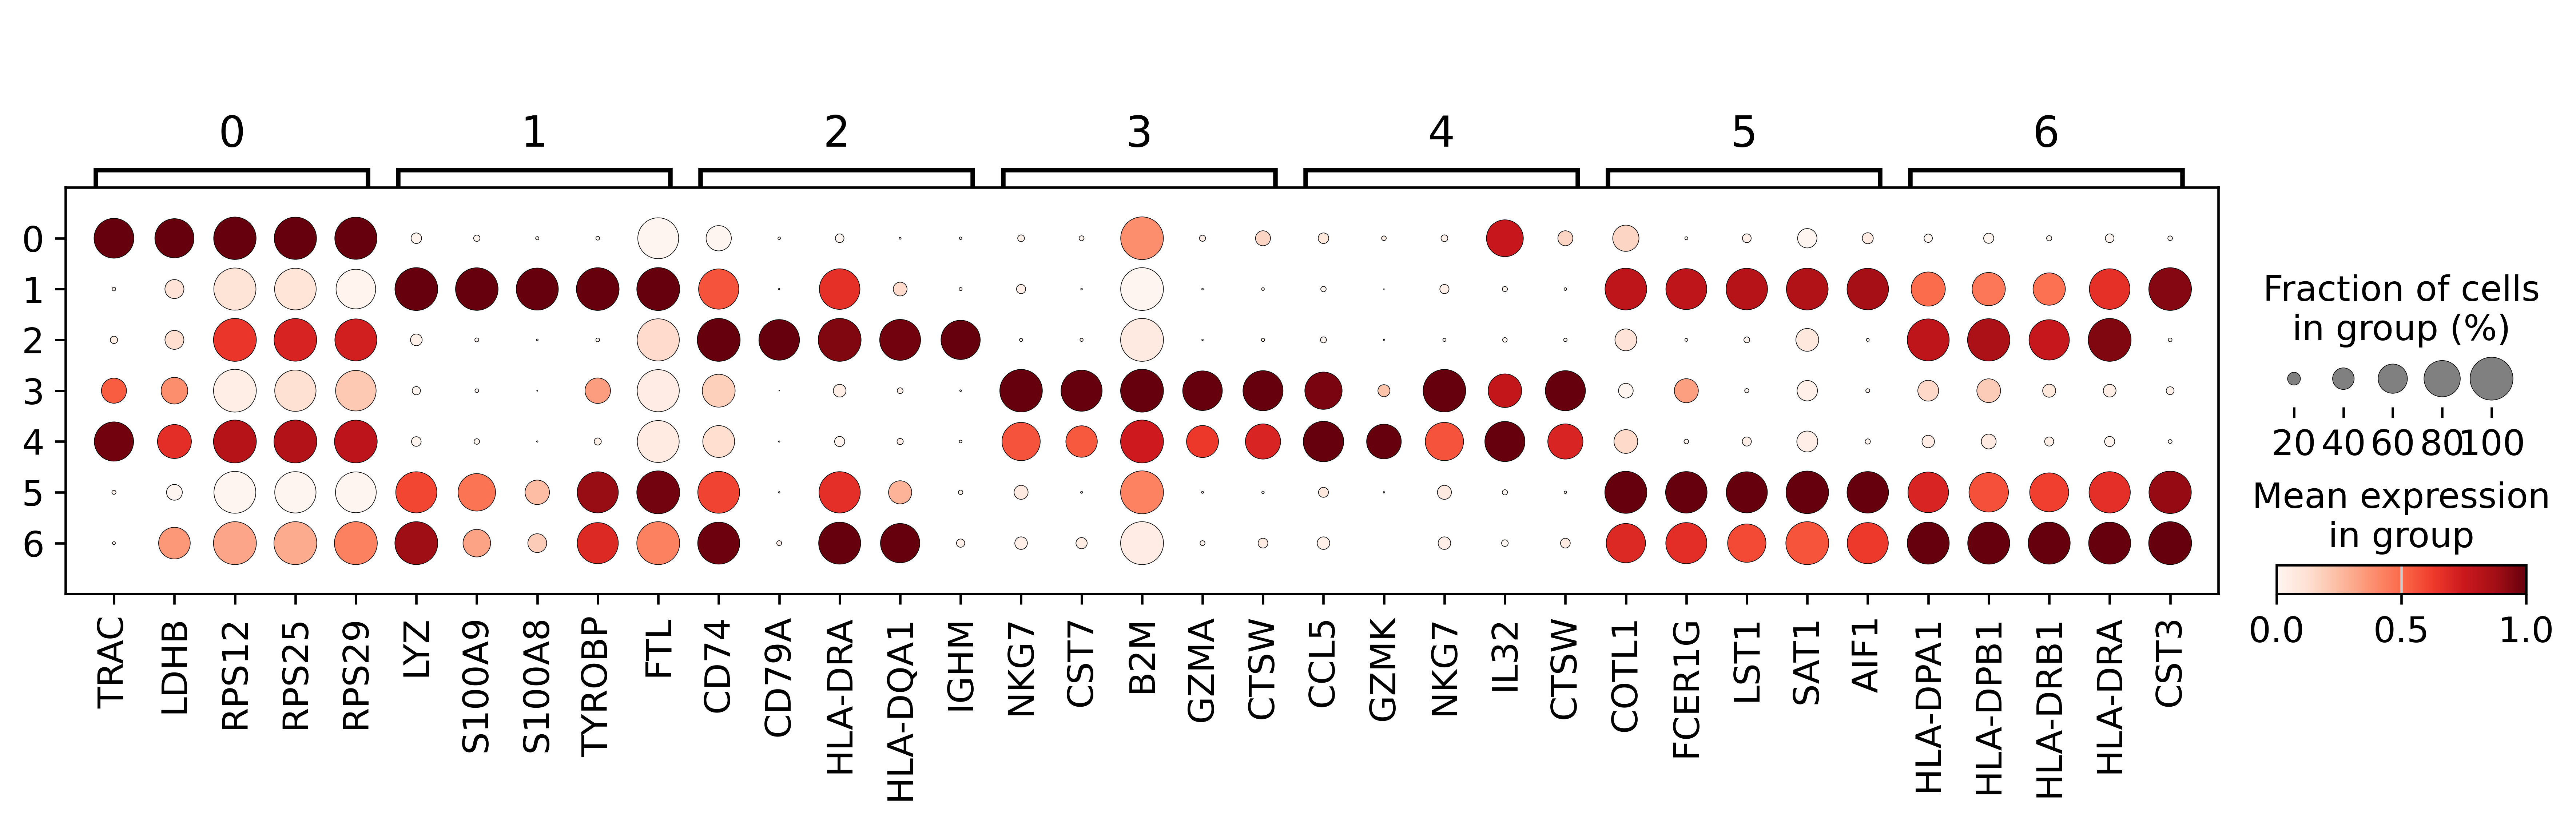

In [ ]:
# Generate a dot plot showing the top five markers per cluster.
top_5_markers = (top_markers.sort_values(['group', 'scores'], ascending=[True, False]).groupby('group').head(5))
marker_dict = (top_5_markers.groupby('group')['names'].apply(list).to_dict())
sc.pl.dotplot(adata, marker_dict, groupby='leiden', use_raw=True, standard_scale='var')
plt.savefig("../results/markers/figures/top_5_markers_dotplot.png", dpi=300, bbox_inches="tight")
plt.close()

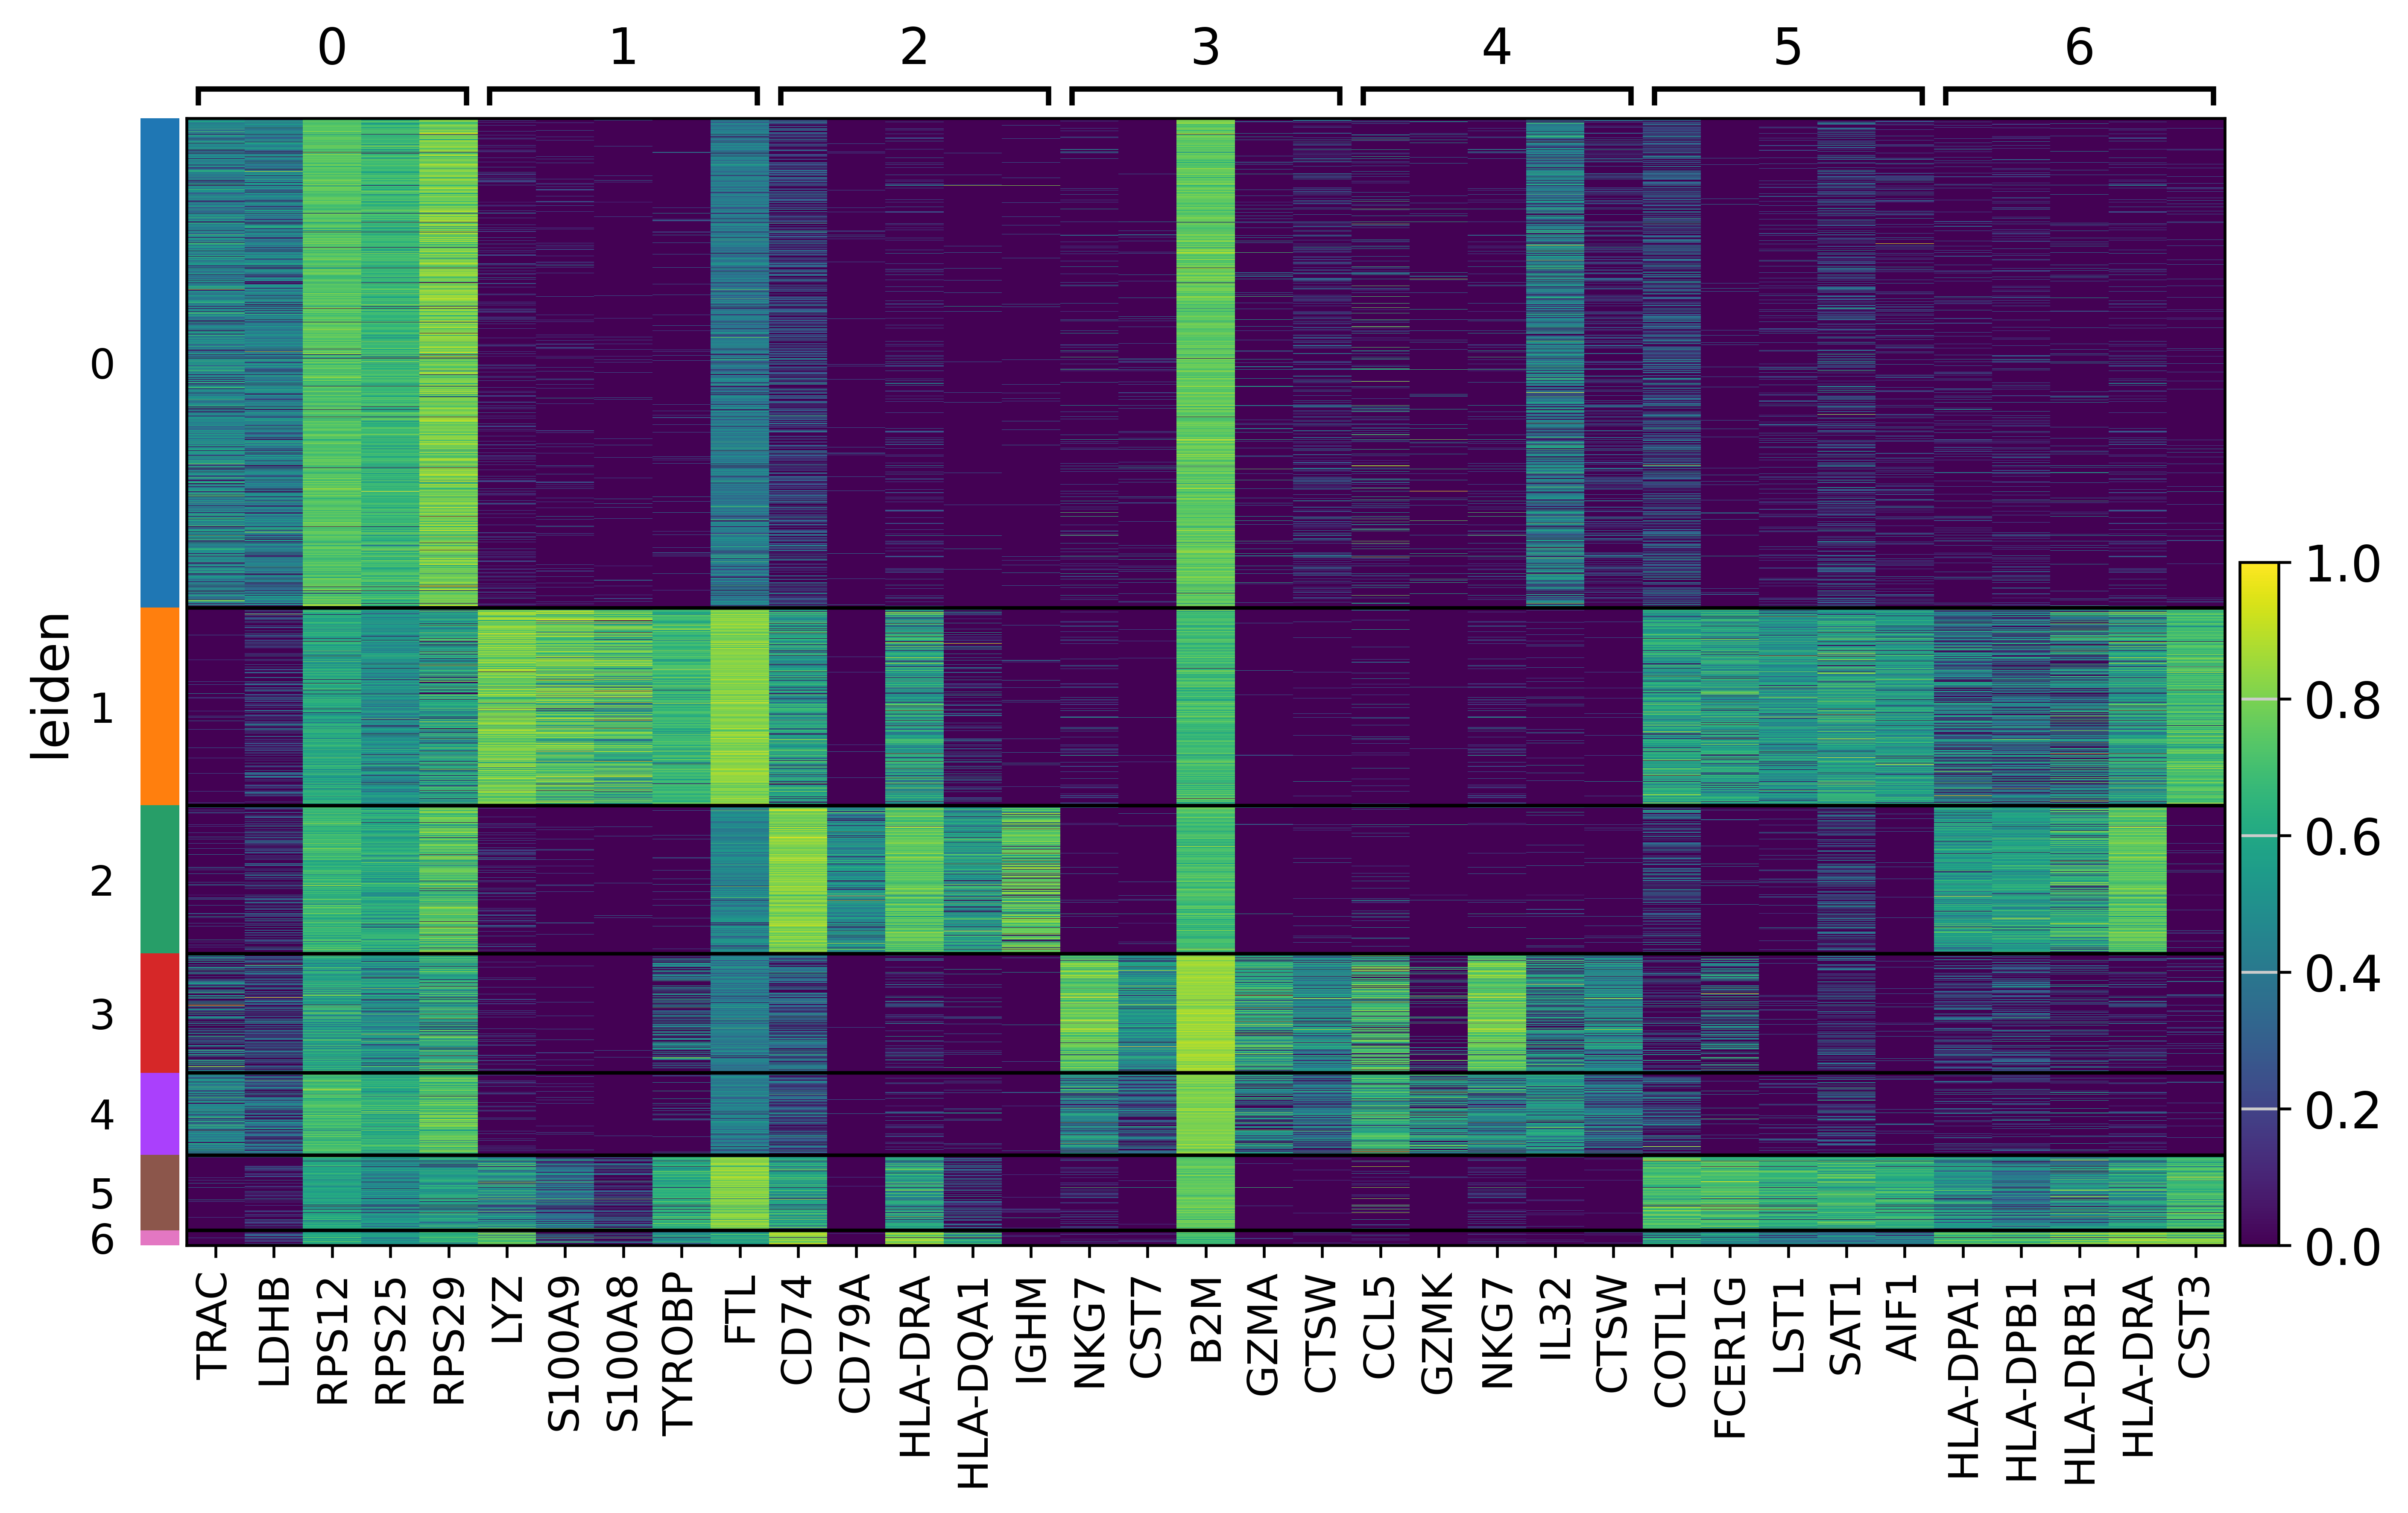

In [ ]:
# Generate a heatmap displaying the top ten markers per cluster.
top_10_marker_dict = (top_markers.groupby('group')['names'].apply(list).to_dict())
sc.pl.heatmap(adata, top_10_marker_dict, groupby='leiden', use_raw=True, standard_scale='var')
plt.savefig("../results/markers/figures/top_10_markers_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

## 6. Canonical Marker Validation

Canonical lineage markers defined in advance will be used to validate biological cluster identity.

This step avoids manual cherry-picking of genes after seeing the data.

In [ ]:
# Extract canonical marker genes from the configuration file.
marker_genes = config['markers']

In [ ]:
# Check which canonical markers are significantly enriched in each cluster.
canonical_markers = [gene for genes in marker_genes.values() for gene in genes]
canonical_hits = filtered_results[filtered_results['names'].isin(canonical_markers)]
print(f"Canonical Markers detected: {len(canonical_hits)}")
canonical_hits.head()

Canonical Markers detected: 27


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
7,0,CD3D,27.171516,3.077571,1.410292e-162,2.194198e-159,0.849280,0.225618
21,0,CD3E,24.160309,2.785533,5.818178e-129,3.922616e-126,0.744285,0.213914
27,0,IL7R,23.198858,3.163894,4.675561e-119,2.555889e-116,0.655377,0.137841
97,0,CCR7,14.300150,3.135138,2.183380e-46,2.742922e-44,0.380186,0.061118
20243,1,LST1,28.008661,4.742152,1.274423e-172,1.356657e-169,0.955975,0.181980


In [ ]:
# Create a table mapping clusters to canonical lineage markers detected.
cluster_marker_table = (canonical_hits.groupby('group')['names'].apply(list).reset_index().rename(columns={"group": "cluster", "names": "detected_canonical_markers"}))
cluster_marker_table

,cluster,detected_canonical_markers
0,0,"[CD3D, CD3E, IL7R, CCR7]"
1,1,"[LST1, CD14, HLA-DRA]"
2,2,"[CD79A, HLA-DRA, MS4A1]"
3,3,"[NKG7, GZMA, GNLY, FCGR3A, CD8A]"
4,4,"[NKG7, GZMA, IL7R, CD3D, CD8A, CD3E]"
5,5,"[LST1, FCGR3A, HLA-DRA, ITGAX]"
6,6,"[HLA-DRA, LST1]"


In [ ]:
# Save the canonical marker validation table to the marker results directory.
output_path = '../results/markers/canonical_marker_validation.csv'
cluster_marker_table.to_csv(output_path, index=False)
print(f"Canonical Marker validation saved to {output_path}")

Canonical Marker validation saved to ../results/markers/canonical_marker_validation.csv


## 7. Marker Stability Across Resolutions

Marker stability will be assessed by comparing marker genes identified across clustering resolutions.

This step is used only as a robustness check rather than as a selection criterion.

In [ ]:
# Repeat differential expression analysis for the lower clustering resolution.
de_cfg = config['pipeline']['de_analysis']
sc.tl.rank_genes_groups(adata, groupby='leiden_0_5', method=de_cfg["test"], corr_method=de_cfg["correction"], pts=True, use_raw=True, key_added="de_leiden_0_5")

results_0_5 = sc.get.rank_genes_groups_df(adata, group=None, key="de_leiden_0_5")

de_cfg = config['pipeline']['de_analysis']
filtered_results_0_5 = results_0_5[(results_0_5['pvals_adj'] < de_cfg['alpha']) & (results_0_5['logfoldchanges'] > de_cfg['min_log2fc']) & (results_0_5["pct_nz_group"] >= de_cfg["min_pct"])]

top_markers_0_5 = (filtered_results_0_5.sort_values(['group', 'scores'], ascending=[True, False]).groupby('group').head(10))

ranking genes
    finished: added to `.uns['de_leiden_0_5']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


In [ ]:
# Repeat differential expression analysis for the higher clustering resolution.
de_cfg = config['pipeline']['de_analysis']
sc.tl.rank_genes_groups(adata, groupby='leiden_1_5', method=de_cfg["test"], corr_method=de_cfg["correction"], pts=True, use_raw=True, key_added='de_leiden_1_5')

results_1_5 = sc.get.rank_genes_groups_df(adata, group=None, key="de_leiden_1_5")

de_cfg = config['pipeline']['de_analysis']
filtered_results_1_5 = results_1_5[(results_1_5['pvals_adj'] < de_cfg['alpha']) & (results_1_5['logfoldchanges'] > de_cfg['min_log2fc']) & (results_1_5["pct_nz_group"] >= de_cfg["min_pct"])]

top_markers_1_5 = (filtered_results_1_5.sort_values(['group', 'scores'], ascending=[True, False]).groupby('group').head(10))

ranking genes
    finished: added to `.uns['de_leiden_1_5']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


In [ ]:
# Compare the top markers across resolutions for each major cluster.
markers_05 = top_markers_0_5.groupby("group")["names"].apply(set)
markers_10 = top_markers.groupby("group")["names"].apply(set)
markers_15 = top_markers_1_5.groupby("group")["names"].apply(set)

In [ ]:
def pairwise_marker_overlap(markers_a, markers_b, res_a, res_b):
    expected_columns = [
        f"{res_a}_cluster",
        f"{res_b}_cluster",
        f"{res_a}_n_markers",
        f"{res_b}_n_markers",
        "n_overlap",
        "jaccard",
        "overlap_coef",
        "overlap_genes",
    ]

    rows = []

    for cluster_a, genes_a in markers_a.items():
        for cluster_b, genes_b in markers_b.items():
            inter = genes_a & genes_b
            union = genes_a | genes_b

            n_a = len(genes_a)
            n_b = len(genes_b)
            n_inter = len(inter)
            n_union = len(union)

            rows.append({
                f"{res_a}_cluster": cluster_a,
                f"{res_b}_cluster": cluster_b,
                f"{res_a}_n_markers": n_a,
                f"{res_b}_n_markers": n_b,
                "n_overlap": n_inter,
                "jaccard": n_inter / n_union if n_union > 0 else 0.0,
                "overlap_coef": n_inter / min(n_a, n_b) if min(n_a, n_b) > 0 else 0.0,
                "overlap_genes": ", ".join(sorted(inter)),
            })

    return pd.DataFrame(rows, columns=expected_columns)

def best_matches(overlap_df, source_col):
    if overlap_df.empty:
        return pd.DataFrame(columns=overlap_df.columns)

    return (
        overlap_df
        .sort_values(by=["jaccard", "overlap_coef", "n_overlap"], ascending=[False, False, False])
        .groupby(source_col, as_index=False)
        .first()
    )

def summarize_best_matches(best_df, comparison_name):
    if best_df.empty:
        return {
            "comparison": comparison_name,
            "mean_best_jaccard": pd.NA,
            "median_best_jaccard": pd.NA,
            "mean_best_overlap_coef": pd.NA,
            "median_best_overlap_coef": pd.NA,
            "mean_n_overlap": pd.NA,
            "median_n_overlap": pd.NA,
        }

    return {
        "comparison": comparison_name,
        "mean_best_jaccard": best_df["jaccard"].mean(),
        "median_best_jaccard": best_df["jaccard"].median(),
        "mean_best_overlap_coef": best_df["overlap_coef"].mean(),
        "median_best_overlap_coef": best_df["overlap_coef"].median(),
        "mean_n_overlap": best_df["n_overlap"].mean(),
        "median_n_overlap": best_df["n_overlap"].median(),
    }

print("n clusters at res 0.5:", len(markers_05))
print("n clusters at res 1.0:", len(markers_10))
print("n clusters at res 1.5:", len(markers_15))

overlap_05_10 = pairwise_marker_overlap(markers_05, markers_10, "res_0_5", "res_1_0")
overlap_10_15 = pairwise_marker_overlap(markers_10, markers_15, "res_1_0", "res_1_5")
overlap_05_15 = pairwise_marker_overlap(markers_05, markers_15, "res_0_5", "res_1_5")

print("overlap_05_10 shape:", overlap_05_10.shape)
print("overlap_10_15 shape:", overlap_10_15.shape)
print("overlap_05_15 shape:", overlap_05_15.shape)

best_05_10 = best_matches(overlap_05_10, "res_0_5_cluster")
best_10_15 = best_matches(overlap_10_15, "res_1_0_cluster")
best_05_15 = best_matches(overlap_05_15, "res_0_5_cluster")

marker_stability_summary = pd.DataFrame([
    summarize_best_matches(best_05_10, "0.5_vs_1.0"),
    summarize_best_matches(best_10_15, "1.0_vs_1.5"),
    summarize_best_matches(best_05_15, "0.5_vs_1.5"),
])

marker_stability_summary

n clusters at res 0.5: 5
n clusters at res 1.0: 7
n clusters at res 1.5: 8
overlap_05_10 shape: (35, 8)
overlap_10_15 shape: (56, 8)
overlap_05_15 shape: (40, 8)


,comparison,mean_best_jaccard,median_best_jaccard,mean_best_overlap_coef,median_best_overlap_coef,mean_n_overlap,median_n_overlap
0,0.5_vs_1.0,0.472727,0.500000,0.960000,1.0,4.800000,5.0
1,1.0_vs_1.5,0.464286,0.500000,0.942857,1.0,4.714286,5.0
2,0.5_vs_1.5,0.623710,0.538462,0.740000,0.7,7.400000,7.0


In [ ]:
# Save the marker stability comparison table.
output_path = Path("../results/markers")
output_path.mkdir(parents=True, exist_ok=True)

marker_stability_summary.to_csv(output_path / "marker_stability_summary.csv", index=False)
best_05_10.to_csv(output_path / "marker_overlap_best_matches_0_5_vs_1_0.csv", index=False)
best_10_15.to_csv(output_path / "marker_overlap_best_matches_1_0_vs_1_5.csv", index=False)
best_05_15.to_csv(output_path / "marker_overlap_best_matches_0_5_vs_1_5.csv", index=False)

## 8. Quality Control Checks

Clusters must be checked to ensure they are not driven primarily by technical artifacts.

In [ ]:
# Evaluate whether mitochondrial genes dominate the marker lists of any cluster.
mt_genes = adata.var_names[adata.var["mt"]].tolist()
filtered_results_sorted = filtered_results.sort_values(by=['group', 'logfoldchanges', 'pvals_adj'], ascending=[True, False, True]).copy()
top_markers = filtered_results_sorted.groupby('group').head(10).copy()
top_markers['is_mt'] = top_markers['names'].isin(mt_genes)

mt_summary = (top_markers.groupby('group').agg(total_top_markers=('names', 'count'), mt_marker_count=('is_mt', 'sum'), mt_marker_genes=('names', lambda x: [g for g in x if g in mt_genes])).reset_index())
mt_summary['mt_fraction'] = mt_summary['mt_marker_count'] / mt_summary['total_top_markers']

print(mt_summary)

  group  total_top_markers  mt_marker_count mt_marker_genes  mt_fraction
0     0                 10                0              []          0.0
1     1                 10                0              []          0.0
2     2                 10                0              []          0.0
3     3                 10                0              []          0.0
4     4                 10                0              []          0.0
5     5                 10                0              []          0.0
6     6                 10                0              []          0.0


In [ ]:
output_path = "../results/markers/mitochondrial_marker_check.csv"
mt_summary.to_csv(output_path, index=False)
print(f"Mitochondrial marker check saved to {output_path}")

Mitochondrial marker check saved to ../results/markers/mitochondrial_marker_check.csv


In [ ]:
# Evaluate whether ribosomal genes dominate the marker lists of any cluster.
ribo_genes = adata.var_names[adata.var['ribo']].tolist()
filtered_results_sorted = filtered_results.sort_values(by=['group', 'logfoldchanges', 'pvals_adj'], ascending=[True, False, True]).copy()
top_markers = filtered_results_sorted.groupby('group').head(10).copy()
top_markers['is_ribo'] = top_markers['names'].isin(ribo_genes)

ribo_summary = (top_markers.groupby('group').agg(total_top_markers=('names', 'count'), ribo_marker_count=('is_ribo', 'sum'), ribo_marker_genes=('names', lambda x: [g for g in x if g in ribo_genes])).reset_index())
ribo_summary['ribo_fraction'] = ribo_summary['ribo_marker_count'] / ribo_summary['total_top_markers']

print(ribo_summary)

  group  total_top_markers  ribo_marker_count ribo_marker_genes  ribo_fraction
0     0                 10                  0                []            0.0
1     1                 10                  0                []            0.0
2     2                 10                  0                []            0.0
3     3                 10                  0                []            0.0
4     4                 10                  0                []            0.0
5     5                 10                  0                []            0.0
6     6                 10                  0                []            0.0


## 9. Summary Statistics

Summary statistics will provide an overview of marker discovery results.

In [ ]:
# Report the number of markers identified per cluster after filtering.
marker_counts = (filtered_results.groupby("group") .agg(num_markers=("names", "count")).reset_index())

print(marker_counts)

  group  num_markers
0     0          348
1     1          461
2     2          233
3     3          333
4     4          105
5     5          905
6     6          287


In [ ]:
# Identify clusters that contain at least two canonical lineage markers and are therefore ready for biological annotation.
clusters_ready = (canonical_hits.groupby("group").agg(num_canonical_markers=("names", "nunique"), markers=("names", lambda x: list(set(x)))).reset_index())

clusters_ready = clusters_ready[clusters_ready["num_canonical_markers"] >= 2]

print(clusters_ready)

  group  num_canonical_markers                               markers
0     0                      4              [CD3D, IL7R, CCR7, CD3E]
1     1                      3                 [HLA-DRA, CD14, LST1]
2     2                      3               [CD79A, HLA-DRA, MS4A1]
3     3                      5      [GNLY, GZMA, CD8A, FCGR3A, NKG7]
4     4                      6  [CD3E, GZMA, CD8A, IL7R, CD3D, NKG7]
5     5                      4        [ITGAX, HLA-DRA, FCGR3A, LST1]
6     6                      2                       [HLA-DRA, LST1]


In [ ]:
# Identify clusters lacking canonical markers and therefore considered ambiguous.
canonical_counts = (canonical_hits.groupby("group").agg(num_canonical_markers=("names", "nunique")).reset_index())
all_clusters = filtered_results["group"].unique()
canonical_counts_full = (pd.DataFrame({"group": all_clusters}).merge(canonical_counts, on="group", how="left").fillna(0))

canonical_counts_full["num_canonical_markers"] = canonical_counts_full["num_canonical_markers"].astype(int)
ambiguous_clusters = canonical_counts_full[canonical_counts_full["num_canonical_markers"] == 0]

print(ambiguous_clusters)

Empty DataFrame
Columns: [group, num_canonical_markers]
Index: []


In [ ]:
# Summarize marker stability across clustering resolutions.
def compute_overlap(series1, series2):
    results = []

    for c1, genes1 in series1.items():
        genes1 = set(genes1)

        best_score = 0
        best_match = None

        for c2, genes2 in series2.items():
            genes2 = set(genes2)

            intersection = len(genes1 & genes2)
            union = len(genes1 | genes2)

            score = intersection / union if union > 0 else 0

            if score > best_score:
                best_score = score
                best_match = c2

        results.append({
            "cluster_res1": c1,
            "best_match_res2": best_match,
            "jaccard_score": best_score
        })

    return pd.DataFrame(results)

overlap_05_10 = compute_overlap(markers_05, markers_10)
overlap_10_15 = compute_overlap(markers_10, markers_15)
overlap_05_15 = compute_overlap(markers_05, markers_15)

summary = pd.DataFrame({
    "comparison": ["0.5 vs 1.0", "1.0 vs 1.5", "0.5 vs 1.5"],
    "mean_jaccard": [
        overlap_05_10["jaccard_score"].mean(),
        overlap_10_15["jaccard_score"].mean(),
        overlap_05_15["jaccard_score"].mean()
    ]
})

print(summary)

   comparison  mean_jaccard
0  0.5 vs 1.0      0.472727
1  1.0 vs 1.5      0.464286
2  0.5 vs 1.5      0.623710


## 10. Save Results

All marker analysis outputs will be saved for downstream cell-type annotation.

In [ ]:
# Save the full marker analysis results.
filtered_results.to_csv("../results/markers/all_filtered_markers.csv", index=False)

print("Saved: all_filtered_markers.csv")

Saved: all_filtered_markers.csv


In [ ]:
# Save summary tables including top markers, canonical marker matches, and stability results.
top_markers.to_csv("../results/markers/top10_markers_per_cluster.csv", index=False)
cluster_marker_table.to_csv("../results/markers/canonical_marker_validation.csv", index=False)
mt_summary.to_csv("../results/markers/mitochondrial_marker_check.csv", index=False)
ribo_summary.to_csv("../results/markers/ribosomal_marker_check.csv", index=False)
marker_counts.to_csv("../results/markers/marker_counts_per_cluster.csv", index=False)
clusters_ready.to_csv("../results/markers/clusters_ready_for_annotation.csv", index=False)
ambiguous_clusters.to_csv("../results/markers/ambiguous_clusters.csv", index=False)

In [ ]:
overlap_05_10.to_csv("../results/markers/stability_05_vs_10.csv", index=False)
overlap_10_15.to_csv("../results/markers/stability_10_vs_15.csv", index=False)
overlap_05_15.to_csv("../results/markers/stability_05_vs_15.csv", index=False)

summary.to_csv("../results/markers/stability_summary.csv", index=False)

In [ ]:
# Document the file paths of all saved outputs.
outputs = {
    "all_markers": "../results/markers/all_filtered_markers.csv",
    "top_markers": "../results/markers/top10_markers_per_cluster.csv",
    "canonical_validation": "../results/markers/canonical_marker_validation.csv",
    "mitochondrial_check": "../results/markers/mitochondrial_marker_check.csv",
    "ribosomal_check": "../results/markers/ribosomal_marker_check.csv",
    "marker_counts": "../results/markers/marker_counts_per_cluster.csv",
    "clusters_ready": "../results/markers/clusters_ready_for_annotation.csv",
    "ambiguous_clusters": "../results/markers/ambiguous_clusters.csv",
    "stability_summary": "../results/markers/stability_summary.csv"
}

import json
with open("../results/markers/output_manifest.json", "w") as f:
    json.dump(outputs, f, indent=4)

print("Saved: output_manifest.json")

Saved: output_manifest.json


## 11. Summary

The differential expression analysis identified marker genes for all 7 clusters at the primary resolution (1.0). After filtering by statistical thresholds (adjusted p-value < 0.05, log2FC > 0.25, expression frequency ≥ 25%), clusters exhibited varying numbers of markers (ranging from 105 to 905 per cluster).

All clusters are ready for biological annotation, as each contains at least 2 canonical lineage markers:
- Cluster 0: 4 markers (CD3D, IL7R, CCR7, CD3E) - likely naive T cells
- Cluster 1: 3 markers (HLA-DRA, CD14, LST1) - likely monocytes
- Cluster 2: 3 markers (CD79A, HLA-DRA, MS4A1) - likely B cells
- Cluster 3: 5 markers (GNLY, GZMA, CD8A, FCGR3A, NKG7) - likely NK cells
- Cluster 4: 6 markers (CD3E, GZMA, CD8A, IL7R, CD3D, NKG7) - likely cytotoxic T cells
- Cluster 5: 4 markers (ITGAX, HLA-DRA, FCGR3A, LST1) - likely dendritic cells
- Cluster 6: 2 markers (HLA-DRA, LST1) - likely myeloid cells

No clusters were identified as ambiguous (i.e., lacking canonical markers).

Marker stability across resolutions is moderate to good, with Jaccard indices of 0.47 (0.5 vs 1.0), 0.46 (1.0 vs 1.5), and 0.62 (0.5 vs 1.5), indicating reasonable robustness with some resolution-dependent variation in secondary markers.

Clusters 3 and 4 show expected marker overlap between NK cells and cytotoxic CD8+ T cells (NKG7, GZMA are shared). Cluster 3 is annotated as NK based on absence of CD3D/CD3E; Cluster 4 as CD8+ T based on presence of CD3 complex markers. This distinction will be validated in annotation phase.

Cluster 6 has only 2 canonical markers (HLA-DRA, LST1), both shared across multiple myeloid lineages. This cluster is provisionally labeled 'myeloid' pending further investigation during annotation.

Marker counts per cluster range from 105 (Cluster X) to 905 (Cluster Y), reflecting variation in transcriptional distinctiveness.

Quality control checks confirmed no clusters are dominated by technical artifacts: no mitochondrial or ribosomal genes appear in the top 10 markers for any cluster.

All results are saved in `../results/markers/` for downstream cell-type annotation.